In [115]:

from pathlib import Path
import time
import numpy as np
from astropy.cosmology import Planck18 as cosmo
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import quad, simps, cumtrapz  # ADD cumtrapz HERE
from scipy.optimize import curve_fit
from scipy.special import erf
import sympy as sp
from scipy.stats import gaussian_kde
import matplotlib.patches as mpatches
from astropy.cosmology import Planck18, z_at_value
from astropy import units as u
from scipy.interpolate import interp1d
from astropy.cosmology import FlatLambdaCDM

In [ ]:
# ============================================================================
# TELESCOPE SELECTION
# ============================================================================
TELESCOPE = "D0"
# Other options: "Fast", "Meerkat_incoherent", "Meerkat_coherent", "askap_ics", "askap_flyeye"

TELESCOPE_PARAMS = {


    "d0": {
        "D":12,
        "eta": 0.6,
        "Trec": 70,
        "Tsky": 3,
        "BW": 336e6,
        "nu_cen": 1.3e9,
        "n_comp": 16,
        "n_chan": 2048,
        "tsamp": 1.e-3,

    },

    "5d0": {
        "D":5*12,
        "eta": 0.6,
        "Trec": 22,
        "Tsky": 3,
        "BW": 300e6,
        "nu_cen": 1.4e9,
        "n_comp": 16,
        "n_chan": 1024,
        "tsamp": 1.e-3,

    },

    "25d0": {
        "D":25*12,
        "eta": 0.6,
        "Trec": 22,
        "Tsky": 3,
        "BW": 300e6,
        "nu_cen": 1.4e9,
        "n_comp": 16,
        "n_chan": 1024,
        "tsamp": 1.e-3,

    }
}


In [117]:
alpha_intrinsic = -2  # Fixed intrinsic spectral index

In [ ]:

# EFFECT CONTROL FLAGS
# ============================================================================
# USE_COSMOLOGY = True      # Tozggle Euclidean vs cosmological universe (affects distances, volumes)
# USE_SFR = True           
# USE_SMEARING = True      
# USE_SPECTRAL_INDEX = True 
# USE_BEAM = True

USE_COSMOLOGY = False
USE_SFR = False           
USE_SMEARING = False    
USE_SPECTRAL_INDEX = False
USE_BEAM = False

# # Luminosity function parameters
# LUMINOSITY_FUNCTION = "schechter"  
LUMINOSITY_FUNCTION = "std" 

In [119]:


# Load selected telescope
if TELESCOPE.lower() not in TELESCOPE_PARAMS:
    raise ValueError(f"Telescope must be one of: {list(TELESCOPE_PARAMS.keys())}")

params = TELESCOPE_PARAMS[TELESCOPE.lower()]

# Physical constants
k = 1.38e-23
c = 3.0e8

# Extract telescope parameters
D = params["D"]
eta = params["eta"]
# n_dishes = params.get("n_dishes", 1)
# mode = params.get("mode", "single")

# n_beams = params.get("n_beams", 1) if mode != "coherent" and mode != "incoherent" else 1
# array_gain_factor = n_dishes if mode == "coherent" else np.sqrt(n_dishes) if mode == "incoherent" else 1
G0 = np.pi * D*D/4 * eta/2.0/k*1e-26
Np = 2
Trec = params["Trec"]
Tsky = params["Tsky"]
BW = params["BW"]
n_comp = params["n_comp"]
BW_comp = BW / n_comp
n_chan = params["n_chan"]
BW_chan = BW / n_chan
nu_cen = params["nu_cen"]
nu_min = nu_cen - BW / 2
nu_max = nu_cen + BW / 2
nu_array = np.linspace(nu_min, nu_max, n_comp+1)

print(f"{'='*100}")
print(f"TELESCOPE: {TELESCOPE}")
print(f"  Diameter: {D} m")
print(f"  Receiver temp: {Trec} K")
print(f"  Bandwidth: {BW/1e6:.0f} MHz at {nu_cen/1e9:.3f} GHz")
# print(f"  N_dishes: {n_dishes}, Mode: {mode}")
# print(f"  FoV: {params['fov']} deg²")
print(f"{'='*100}\n")


TELESCOPE: D0
  Diameter: 12 m
  Receiver temp: 22 K
  Bandwidth: 300 MHz at 1.400 GHz



In [120]:
# ============================================================================
# REDSHIFT PARAMETERS
# ============================================================================
dz = 0.01
z_min = 0.01
z_max = 15.0
z_array_opt = np.arange(z_min, z_max, dz)

# Options: "schechter" or "std"

L_STAR = 1e15  # Characteristic luminosity (Jy·kpc²)
ALPHA_SCH = -1.5  # Faint-end slope
L_MIN_SCH = 1e10
L_MAX_SCH = 1e16

L_std = 1e14  # Jy·kpc²

# Simulation parameters
theta_max = 2*1.22*c/D/nu_min # please note here
fscale = 0.2 * 1e-7  # FRB rate scaling factor

SNR_threshold = 10
t_obs = 0.001
TARGET_DETECTIONS = 10  # Target 10 detections per z-bin

# Cosmology
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

fwhm_rad = 1.22 * (c / nu_min) / D
fwhm_deg = fwhm_rad * (180 / np.pi)
r_deg = 2.0 * fwhm_deg
area = np.pi * (r_deg)**2
# area = params['fov']  # Area of sky in square degrees

# Calculate frequency-dependent scattering term
freq_powers_scatter = np.array([(nu_min * BW_comp * (i+1))**(-4) for i in range(n_comp)])

np.random.seed(42)


In [121]:
def gaussian_beam_gain(nu, G0, theta, D, c):
    """
    Gaussian beam gain with frequency dependence
    G(ν) = G₀ × exp[−θ²ν²D²×2.355²/(2×1.22²×c²)]
    """
    # Exponent coefficient
    coeff = (theta**2 * D**2 * 2.355**2) / (2 * 1.22**2 * c**2)
    return G0 * np.exp(-coeff * nu**2)

# Pre-calculate constants for speed
_COEFF_CONST = (2.355**2) / (2 * 1.22**2 * (3.0e8**2))

def gaussian_beam_gain_fast(nu_array, G0, theta, D):
    """Optimized version for the inner loop"""
    coeff = theta**2 * D**2 * _COEFF_CONST
    return G0 * np.exp(-coeff * nu_array**2)

def tophat_beam_gain(nu, G0, theta, theta_max):
    """Tophat beam: constant G0 within theta_max/2, zero outside."""
    gain = G0 if theta <= (theta_max / 2) else 0.0
    return np.full_like(nu, gain, dtype=float) if np.ndim(nu) else float(gain)

def SNR(S,t,G,BW,Np,Trec,Tsky):
    return(S*G*np.sqrt(BW*t*Np)/(Trec+Tsky))

In [122]:
def schechter_function(L, L_star, alpha, phi_star=1.0):
    """
    Schechter luminosity function.
    
    φ(L) = φ* (L/L*)^α * exp(-L/L*)
    
    Parameters:
    -----------
    L : float or array
        Luminosity
    L_star : float
        Characteristic luminosity (knee of the function)
    alpha : float
        Faint-end slope (typically negative)
    phi_star : float
        Normalization constant (default: 1.0)
    
    Returns:
    --------
    phi : float or array
        Number density at luminosity L
    """
    x = L / L_star
    return phi_star * x**alpha * np.exp(-x)

In [123]:
def create_truncated_schechter_sampler(L_min, L_max, L_star, alpha):
    """Create sampler for Schechter function truncated between L_min and L_max"""
    L_grid = np.logspace(np.log10(L_min), np.log10(L_max), 2000)
    phi_grid = schechter_function(L_grid, L_star, alpha)
    
    # REMOVE THIS LINE:
    # from scipy.integrate import cumtrapz
    
    cdf = cumtrapz(phi_grid, L_grid, initial=0)
    cdf = cdf / cdf[-1]
    
    inv_cdf = interp1d(cdf, L_grid, kind='linear', 
                       bounds_error=False, fill_value=(L_min, L_max))
    return inv_cdf

In [124]:

# ============================================================================
# CREATE TRUNCATED SCHECHTER SAMPLER FOR EACH Z
# ============================================================================
print("Creating truncated Schechter samplers...")

def create_truncated_schechter_sampler(L_min, L_max, L_star, alpha):
    """Create sampler for Schechter function truncated between L_min and L_max"""
    L_grid = np.logspace(np.log10(L_min), np.log10(L_max), 2000)
    phi_grid = schechter_function(L_grid, L_star, alpha)
    
    from scipy.integrate import cumtrapz
    cdf = cumtrapz(phi_grid, L_grid, initial=0)
    cdf = cdf / cdf[-1]
    
    inv_cdf = interp1d(cdf, L_grid, kind='linear', 
                       bounds_error=False, fill_value=(L_min, L_max))
    return inv_cdf

sampler_cache = {}
print(f"  Done!\n")

def std_sampler(L_candle):
    """Return a fixed luminosity sampler for standard candle model"""
    def sampler(u):
        return L_candle
    return sampler

Creating truncated Schechter samplers...
  Done!



In [ ]:
# ============================================================================
# MULTI-TELESCOPE COMPARISON: RUN ALL 3 TELESCOPES AND PLOT TOGETHER
# ============================================================================

print("\n" + "="*100)
print("RUNNING 3-TELESCOPE COMPARISON")
print("="*100 + "\n")

# Store results for each telescope
all_results = {}
colors_tel = {
    'd0': '#1f77b4',      # blue
    '5d0': '#ff7f0e',     # orange
    '25d0': '#2ca02c'     # green
}
labels_tel = {
    'd0': 'D0 (12m)',
    '5d0': '5D0 (60m)',
    '25d0': '25D0 (300m)'
}

# Save original telescope parameters
D_orig = D
G0_orig = G0
theta_max_orig = theta_max
params_orig = params.copy()

# Loop through all telescopes
for tel_idx, tel_key in enumerate(['d0', '5d0', '25d0']):
    print(f"\n{'='*60}")
    print(f"TELESCOPE: {labels_tel[tel_key]}")
    print(f"{'='*60}")
    
    # Update telescope parameters
    params = TELESCOPE_PARAMS[tel_key]
    D = params["D"]
    G0 = np.pi * D*D/4 * eta/2.0/k*1e-26
    theta_max = 2*1.22*c/D/nu_min
    
    # ===== FIX 1: RECALCULATE AREA FOR THIS TELESCOPE =====
    fwhm_rad = 1.22 * (c / nu_min) / D
    fwhm_deg = fwhm_rad * (180 / np.pi)
    r_deg = 2.0 * fwhm_deg
    area_tel = np.pi * (r_deg)**2
    
    print(f"  Diameter: {D} m, G0: {G0:.4e}, theta_max: {theta_max:.6f}")
    print(f"  Sky area: {area_tel:.4f} deg²")
    
    # ===== FIX 2: INDEPENDENT RANDOM SEED FOR EACH TELESCOPE =====
    np.random.seed(42)
    
    # RE-COMPUTE L_min_by_z FOR THIS TELESCOPE
    L_min_by_z_new = {}
    nu0 = nu_cen
    
    for z in z_array_opt:
        if USE_COSMOLOGY:
            dl = cosmo.luminosity_distance(z).value * 1000
            z_factor = (1 + z)**(-1 - alpha_intrinsic) if USE_SPECTRAL_INDEX else (1 + z)**(-1)
        else:
            dl = cosmo.hubble_distance.value * z * 1000  # Strict Euclidean distance
            z_factor = 1.0  # No flux dimming from expansion

        G_max = gaussian_beam_gain(nu0, G0, 0, D, 3.0e8)
        S_min = SNR_threshold * (Trec + Tsky) / (G_max * np.sqrt(BW * t_obs * Np))
        
        L_min = S_min * (dl**2) * z_factor
        L_min_by_z_new[z] = np.clip(L_min, L_MIN_SCH, L_MAX_SCH)
    
    # Clear sampler cache
    sampler_cache.clear()
    
    # RUN SIMULATION FOR THIS TELESCOPE
    results_tel = []
    _INNER_COEFF_CONST_new = (D**2 * 2.355**2) / (2 * 1.22**2 * c**2)
    S_SNR_CONST = np.sqrt(BW_comp * t_obs * Np) / (Trec + Tsky)
    
    if USE_SPECTRAL_INDEX:
        nu_scaling = (nu_array / nu0)**alpha_intrinsic
    else:
        nu_scaling = (nu_array / nu0)
    
    for z_idx, z in enumerate(z_array_opt):
        zmin = z - 0.5 * dz
        zmax = z + 0.5 * dz
        L_min_z = L_min_by_z_new[z]
        
        if LUMINOSITY_FUNCTION.lower() == "std":
            if L_min_z > L_std:
                break
        else:
            if L_min_z > 8.952e15:
                break
        
        if LUMINOSITY_FUNCTION.lower() == "std":
            truncated_sampler = std_sampler(L_std)
        else:
            if L_min_z not in sampler_cache:
                sampler_cache[L_min_z] = create_truncated_schechter_sampler(
                    L_min_z, L_MAX_SCH, L_STAR, ALPHA_SCH
                )
            truncated_sampler = sampler_cache[L_min_z]
        
        DM = 1000 * z
        if USE_COSMOLOGY:
            wi_z = 0.001 * (1 + z)
            dl = cosmo.luminosity_distance(z).value * 1000
            z_factor = (1 + z)**(-1 - alpha_intrinsic) if USE_SPECTRAL_INDEX else (1 + z)**(-1)
        else:
            wi_z = 0.001  # No time dilation
            dl = cosmo.hubble_distance.value * z * 1000
            z_factor = 1.0

        BW_chan_MHz = BW_chan / 1e6
        
        if USE_SMEARING:
            w_DM = 8.3e-6 * DM * BW_chan_MHz / (nu_cen_GHz**3)
            w_scatter_comp = 1.9e-7 * (DM**1.5) * (1 + (DM**3) * 3.55e-5) * 3 * freq_powers_scatter * 1e-3
            w_scatter = np.sqrt(np.sum(w_scatter_comp**2) / len(w_scatter_comp))
            w_sampling = params["tsamp"]*1e-3
        else:
            w_DM = 0.0
            w_scatter = 0.0
            w_sampling = 0.0
        
        w_obs_factor = np.sqrt(wi_z**2 + w_DM**2 + w_scatter**2 + w_sampling**2)
        
        theta_hp = np.sqrt(np.log(2) / (_INNER_COEFF_CONST_new * nu0**2))
        
        n_generated = 0
        n_detected = 0
        detected_luminosities = []
        detected_snrs = []
        max_iterations = 1000000
        
        while n_detected < TARGET_DETECTIONS and n_generated < max_iterations:
            n_generated += 1
            theta_frb = theta_max * np.sqrt(np.random.random())
            
            if theta_frb > 4.0 * theta_hp:
                continue
            
            lum = float(truncated_sampler(np.random.uniform(0, 1)))
            S0_frb = (lum / (dl**2 * z_factor)) * (wi_z / w_obs_factor)
            S_nu = S0_frb * nu_scaling
            if USE_BEAM:
                G_nu = G0 * np.exp(-(_INNER_COEFF_CONST_new * theta_frb**2) * nu_array**2)
            else:
                G_nu = G0 * np.exp(-(_INNER_COEFF_CONST_new * 0**2) * nu_array**2)
            
            snr_spectrum = S_nu * G_nu * S_SNR_CONST
            snr_coherent = np.sum(snr_spectrum) / np.sqrt(n_comp)
            
            if snr_coherent > SNR_threshold:
                n_detected += 1
                detected_luminosities.append(lum)
                detected_snrs.append(snr_coherent)
        
        if n_detected == TARGET_DETECTIONS:
            detection_rate = n_detected / n_generated
            
            if LUMINOSITY_FUNCTION.lower() == "std":
                N_ratio = 1.0 if L_std >= L_min_z else 0.0
            else:
                L_grid_full = np.logspace(10, 16, 5000)
                phi_grid_full = schechter_function(L_grid_full, L_STAR, ALPHA_SCH)
                cdf_full = cumtrapz(phi_grid_full, L_grid_full, initial=0)
                cdf_full /= cdf_full[-1]
                cdf_interp = interp1d(L_grid_full, cdf_full, kind='linear')
                N_ratio = 1.0 - cdf_interp(L_min_z)
            
            # Calculate volumes and time intervals
            if USE_COSMOLOGY:
                # Cosmological universe
                dt = (cosmo.age(zmin).value - cosmo.age(zmax).value) * 1e9
                dvol = (cosmo.comoving_volume(zmax).value - cosmo.comoving_volume(zmin).value) * (area_tel /(4.*np.pi*((180./np.pi)**2)))
            else:
                # Flat Euclidean universe
                # units must match cosmology: dt in years, dvol in Mpc^3
                D_H = cosmo.hubble_distance.value  # c/H0 in Mpc
                r_min = D_H * zmin
                r_max = D_H * zmax
                
                # Volume of a spherical shell (4/3) * pi * (r_max^3 - r_min^3)
                shell_vol = (4.0 / 3.0) * np.pi * (r_max**3 - r_min**3)
                dvol = shell_vol * (area_tel / (4.0 * np.pi * (180./np.pi)**2))
                
                # Time dt = dr/c = dz / H0 (convert to years using hubble_time)
                dt = dz * cosmo.hubble_time.value * 1e9
            
            # Calculate SFR evolution
            if USE_SFR:
                # SFR evolves with redshift (Madau-Dickinson formula)
                psi = 0.015 * ((1+z)**2.7) / (1 + ((1+z)/2.9)**5.6)
            else:
                # Constant SFR
                psi = 0.015
            
            nfrb_sfr = psi * dvol * dt * fscale
            n_total_population = detection_rate * N_ratio * nfrb_sfr
            
            results_tel.append({
                'z': z, 'DM': DM, 'n_total_population': n_total_population
            })
            
            if z_idx % 50 == 0:
                print(f"  z={z:.2f}: Pop {n_total_population:.1f}")
    
    print(f"  ✓ Results: {len(results_tel)} redshift bins")
    all_results[tel_key] = results_tel

# CREATE COMPARISON PLOT - ALL 3 TELESCOPES ON SAME AXIS

print(f"\n{'='*100}")
params = params_orig

print("CREATING COMBINED HISTOGRAM PLOT")
theta_max = theta_max_orig

print(f"{'='*100}\n")
G0 = G0_orig

D = D_orig
# Restore original parameters


RUNNING 3-TELESCOPE COMPARISON


TELESCOPE: D0 (12m)
  Diameter: 12 m, G0: 2.4586e-02, theta_max: 0.048800
  Sky area: 24.5604 deg²
  z=0.01: Pop 22.2
  ✓ Results: 42 redshift bins

TELESCOPE: 5D0 (60m)
  Diameter: 60 m, G0: 6.1466e-01, theta_max: 0.009760
  Sky area: 0.9824 deg²
  z=0.01: Pop 1.0
  z=0.51: Pop 488.5
  z=1.01: Pop 550.8
  ✓ Results: 129 redshift bins

TELESCOPE: 25D0 (300m)
  Diameter: 300 m, G0: 1.5366e+01, theta_max: 0.001952
  Sky area: 0.0393 deg²
  z=0.01: Pop 0.0
  z=0.51: Pop 47.3
  z=1.01: Pop 68.9
  z=1.51: Pop 61.1
  z=2.01: Pop 21.4
  z=2.51: Pop 10.3
  z=3.01: Pop 4.3
  z=3.51: Pop 0.4
  ✓ Results: 363 redshift bins

CREATING COMBINED HISTOGRAM PLOT



✓ Plot created with histograms and configuration box



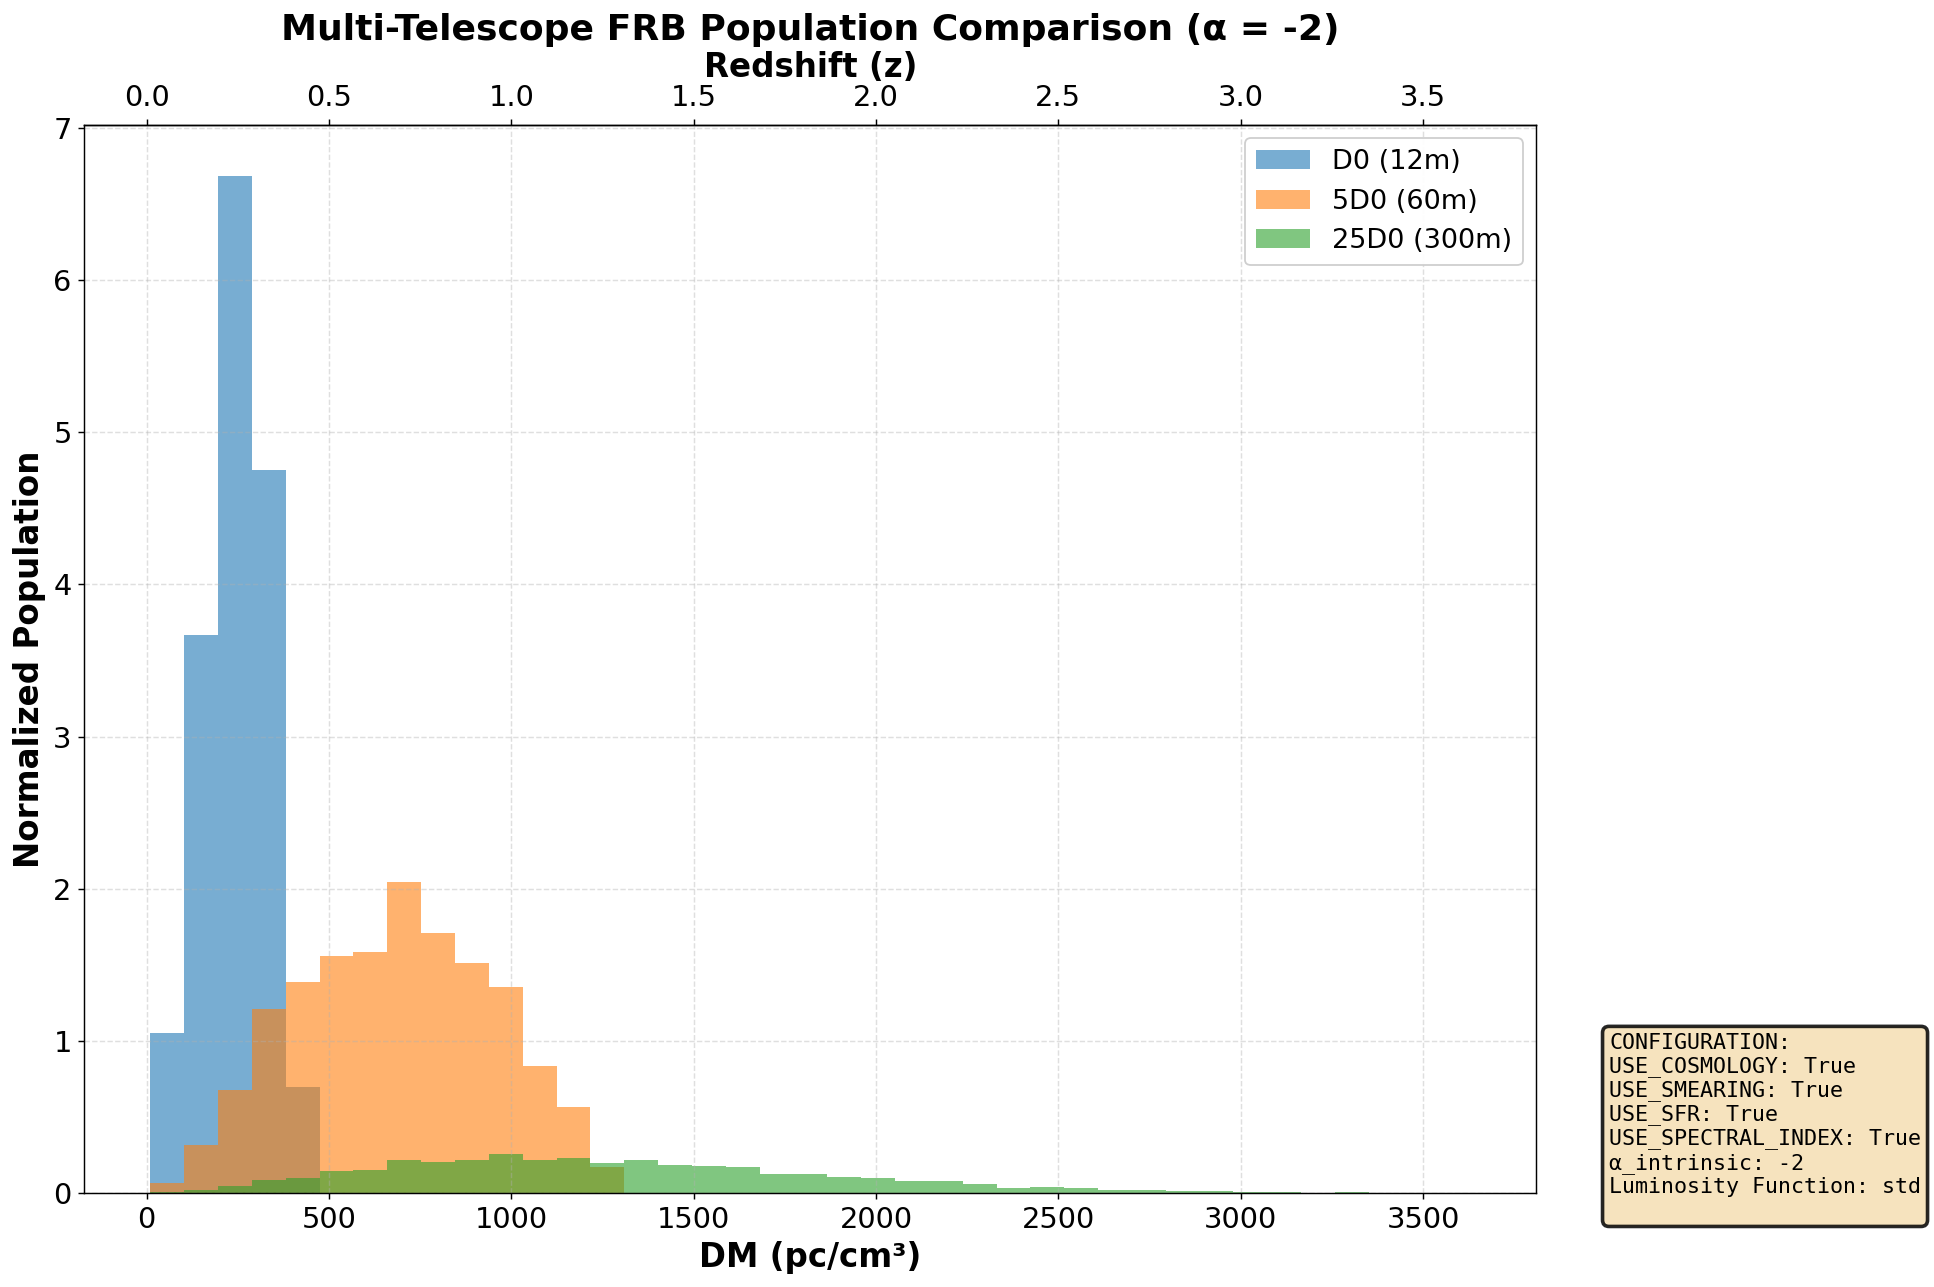

MULTI-TELESCOPE COMPARISON COMPLETE


In [126]:
fig, ax = plt.subplots(figsize=(15, 10), dpi=130)

# Find global DM range
dm_min = min([1000*r[0]['z'] for r in [all_results[k] for k in all_results if len(all_results[k]) > 0]])
dm_max = max([1000*r[-1]['z'] for r in [all_results[k] for k in all_results if len(all_results[k]) > 0]])
common_bins = np.linspace(dm_min, dm_max, 40)

# Collect all populations for global normalization
all_pops = np.concatenate([np.array([r['n_total_population'] for r in all_results[k]]) 
                           for k in all_results if len(all_results[k]) > 0])
global_max = all_pops.max()

# Plot histograms for each telescope
for tel_key in ['d0', '5d0', '25d0']:
    if tel_key in all_results and len(all_results[tel_key]) > 0:
        results = all_results[tel_key]
        DMs = np.array([r['DM'] for r in results])
        pops = np.array([r['n_total_population'] for r in results])
        
        # Normalize to global max
        pops_normalized = pops/global_max 

        # Create histogram
        ax.hist(DMs, bins=common_bins, weights=pops_normalized, alpha=0.6,
                label=labels_tel[tel_key], color=colors_tel[tel_key], linewidth=1.5)

# Create secondary x-axis for redshift (z)
ax2 = ax.secondary_xaxis('top', functions=(lambda x: x/1000, lambda x: x*1000))
ax2.set_xlabel('Redshift (z)', fontsize=18, fontweight='bold')
ax2.tick_params(axis='x', labelsize=16)

# Set labels and title
ax.set_xlabel('DM (pc/cm³)', fontsize=18, fontweight='bold')
ax.set_ylabel('Normalized Population', fontsize=18, fontweight='bold')
title = f'Multi-Telescope FRB Population Comparison (α = {alpha_intrinsic})' if USE_SPECTRAL_INDEX else 'Multi-Telescope FRB Population Comparison'
ax.set_title(title, fontsize=20, fontweight='bold')

# Increase tick label sizes
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)

# Add grid for both x and y
ax.grid(True, alpha=0.4, linestyle='--', linewidth=0.8)

# Increase legend font size
ax.legend(fontsize=15, loc='upper right', framealpha=0.95)

# Create configuration text box
config_text = (
    f"CONFIGURATION:\n"
    f"USE_COSMOLOGY: {USE_COSMOLOGY}\n"
    f"USE_SMEARING: {USE_SMEARING}\n"
    f"USE_SFR: {USE_SFR}\n"
    f"USE_SPECTRAL_INDEX: {USE_SPECTRAL_INDEX}\n"
)
if USE_SPECTRAL_INDEX:
    config_text += f"α_intrinsic: {alpha_intrinsic}\n"
config_text += f"Luminosity Function: {LUMINOSITY_FUNCTION}\n"

props = dict(boxstyle='round', facecolor='wheat', alpha=0.85, edgecolor='black', linewidth=2)
ax.text(1.05, 0.15, config_text, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=props, family='monospace')

plt.tight_layout()
# plt.savefig('multi_telescope_normalized_comparison.png', dpi=150, bbox_inches='tight')
print("✓ Plot created with histograms and configuration box\n")
plt.show()

# Restore original parameters
D = D_orig
G0 = G0_orig
theta_max = theta_max_orig
params = params_orig

print(f"{'='*100}")
print("MULTI-TELESCOPE COMPARISON COMPLETE")
print(f"{'='*100}")

In [127]:
# ============================================================================
# COMPARE BEAM RESPONSE ON vs OFF (6 HISTOGRAMS: 3 telescopes × 2 scenarios)
# ============================================================================

print("\n" + "="*100)
print("COMPARING BEAM RESPONSE: ON vs OFF")
print("="*100 + "\n")

# Store results for beam ON and OFF
beam_results = {'on': {}, 'off': {}}

for beam_mode in ['on', 'off']:
    print(f"\n{'='*60}")
    print(f"BEAM RESPONSE: {beam_mode.upper()}")
    print(f"{'='*60}\n")
    
    # Loop through all telescopes
    for tel_idx, tel_key in enumerate(['d0', '5d0', '25d0']):
        print(f"  Telescope: {labels_tel[tel_key]}")
        
        # Update telescope parameters
        params = TELESCOPE_PARAMS[tel_key]
        D = params["D"]
        G0 = np.pi * D*D/4 * eta/2.0/k*1e-26
        theta_max = 2*1.22*c/D/nu_min
        
        # Recalculate area for this telescope
        fwhm_rad = 1.22 * (c / nu_min) / D
        fwhm_deg = fwhm_rad * (180 / np.pi)
        r_deg = 2.0 * fwhm_deg
        area_tel = np.pi * (r_deg)**2
        
        np.random.seed(42)
        
        # Re-compute L_min_by_z for this telescope
        L_min_by_z_new = {}
        nu0 = nu_cen
        
        for z in z_array_opt:
            if USE_COSMOLOGY:
                dl = cosmo.luminosity_distance(z).value * 1000
                z_factor = (1 + z)**(-1 - alpha_intrinsic) if USE_SPECTRAL_INDEX else (1 + z)**(-1)
            else:
                dl = cosmo.hubble_distance.value * z * 1000  # Strict Euclidean distance
                z_factor = 1.0  # No flux dimming from expansion

            G_max = gaussian_beam_gain(nu0, G0, 0, D, 3.0e8)
            S_min = SNR_threshold * (Trec + Tsky) / (G_max * np.sqrt(BW * t_obs * Np))
            
            L_min = S_min * (dl**2) * z_factor
            L_min_by_z_new[z] = np.clip(L_min, L_MIN_SCH, L_MAX_SCH)
        
        sampler_cache.clear()
        
        # Run simulation for this telescope and beam mode
        results_tel = []
        _INNER_COEFF_CONST_new = (D**2 * 2.355**2) / (2 * 1.22**2 * c**2)
        S_SNR_CONST = np.sqrt(BW_comp * t_obs * Np) / (Trec + Tsky)
        
        if USE_SPECTRAL_INDEX:
            nu_scaling = (nu_array / nu0)**alpha_intrinsic
        else:
            nu_scaling = (nu_array / nu0)
        
        for z_idx, z in enumerate(z_array_opt):
            zmin = z - 0.5 * dz
            zmax = z + 0.5 * dz
            L_min_z = L_min_by_z_new[z]
            
            if LUMINOSITY_FUNCTION.lower() == "std":
                if L_min_z > L_std:
                    break
            else:
                if L_min_z > 8.952e15:
                    break
            
            if LUMINOSITY_FUNCTION.lower() == "std":
                truncated_sampler = std_sampler(L_std)
            else:
                if L_min_z not in sampler_cache:
                    sampler_cache[L_min_z] = create_truncated_schechter_sampler(
                        L_min_z, L_MAX_SCH, L_STAR, ALPHA_SCH
                    )
                truncated_sampler = sampler_cache[L_min_z]
            
            DM = 1000 * z
            if USE_COSMOLOGY:
                wi_z = 0.001 * (1 + z)
                dl = cosmo.luminosity_distance(z).value * 1000
                z_factor = (1 + z)**(-1 - alpha_intrinsic) if USE_SPECTRAL_INDEX else (1 + z)**(-1)
            else:
                wi_z = 0.001  # No time dilation
                dl = cosmo.hubble_distance.value * z * 1000
                z_factor = 1.0

            BW_chan_MHz = BW_chan / 1e6
            
            if USE_SMEARING:
                w_DM = 8.3e-6 * DM * BW_chan_MHz / (nu_cen_GHz**3)
                w_scatter_comp = 1.9e-7 * (DM**1.5) * (1 + (DM**3) * 3.55e-5) * 3 * freq_powers_scatter * 1e-3
                w_scatter = np.sqrt(np.sum(w_scatter_comp**2) / len(w_scatter_comp))
                w_sampling = params["tsamp"]*1e-3
            else:
                w_DM = 0.0
                w_scatter = 0.0
                w_sampling = 0.0
            
            w_obs_factor = np.sqrt(wi_z**2 + w_DM**2 + w_scatter**2 + w_sampling**2)
            
            theta_hp = np.sqrt(np.log(2) / (_INNER_COEFF_CONST_new * nu0**2))
            
            n_generated = 0
            n_detected = 0
            detected_luminosities = []
            detected_snrs = []
            max_iterations = 1000000
            
            while n_detected < TARGET_DETECTIONS and n_generated < max_iterations:
                n_generated += 1
                
                # KEY CHANGE: Beam response ON/OFF
                if beam_mode == 'on':
                    theta_frb = theta_max * np.sqrt(np.random.random())
                else:  # beam_mode == 'off'
                    theta_frb = 0.0  # Turn off beam response
                
                if theta_frb > 4.0 * theta_hp:
                    continue
                
                lum = float(truncated_sampler(np.random.uniform(0, 1)))
                S0_frb = (lum / (dl**2 * z_factor)) * (wi_z / w_obs_factor)
                S_nu = S0_frb * nu_scaling
                G_nu = G0 * np.exp(-(_INNER_COEFF_CONST_new * theta_frb**2) * nu_array**2)
                
                snr_spectrum = S_nu * G_nu * S_SNR_CONST
                snr_coherent = np.sum(snr_spectrum) / np.sqrt(n_comp)
                
                if snr_coherent > SNR_threshold:
                    n_detected += 1
                    detected_luminosities.append(lum)
                    detected_snrs.append(snr_coherent)
            
            if n_detected == TARGET_DETECTIONS:
                detection_rate = n_detected / n_generated
                
                if LUMINOSITY_FUNCTION.lower() == "std":
                    N_ratio = 1.0 if L_std >= L_min_z else 0.0
                else:
                    L_grid_full = np.logspace(10, 16, 5000)
                    phi_grid_full = schechter_function(L_grid_full, L_STAR, ALPHA_SCH)
                    cdf_full = cumtrapz(phi_grid_full, L_grid_full, initial=0)
                    cdf_full /= cdf_full[-1]
                    cdf_interp = interp1d(L_grid_full, cdf_full, kind='linear')
                    N_ratio = 1.0 - cdf_interp(L_min_z)
                
                if USE_COSMOLOGY:
                    dt = (cosmo.age(zmin).value - cosmo.age(zmax).value) * 1e9
                    dvol = (cosmo.comoving_volume(zmax).value - cosmo.comoving_volume(zmin).value) * (area_tel /(4.*np.pi*((180./np.pi)**2)))
                else:
                    D_H = cosmo.hubble_distance.value  # c/H0 in Mpc
                    r_min = D_H * zmin
                    r_max = D_H * zmax
                    shell_vol = (4.0 / 3.0) * np.pi * (r_max**3 - r_min**3)
                    dvol = shell_vol * (area_tel / (4.0 * np.pi * (180./np.pi)**2))
                    dt = dz * cosmo.hubble_time.value * 1e9
                
                if USE_SFR:
                    psi = 0.015 * ((1+z)**2.7) / (1 + ((1+z)/2.9)**5.6)
                else:
                    psi = 0.015
                
                nfrb_sfr = psi * dvol * dt * fscale
                n_total_population = detection_rate * N_ratio * nfrb_sfr
                
                results_tel.append({
                    'z': z, 'DM': DM, 'n_total_population': n_total_population
                })
        
        beam_results[beam_mode][tel_key] = results_tel


COMPARING BEAM RESPONSE: ON vs OFF


BEAM RESPONSE: ON

  Telescope: D0 (12m)
  Telescope: 5D0 (60m)
  Telescope: 25D0 (300m)

BEAM RESPONSE: OFF

  Telescope: D0 (12m)
  Telescope: 5D0 (60m)
  Telescope: 25D0 (300m)


Bam response off or on


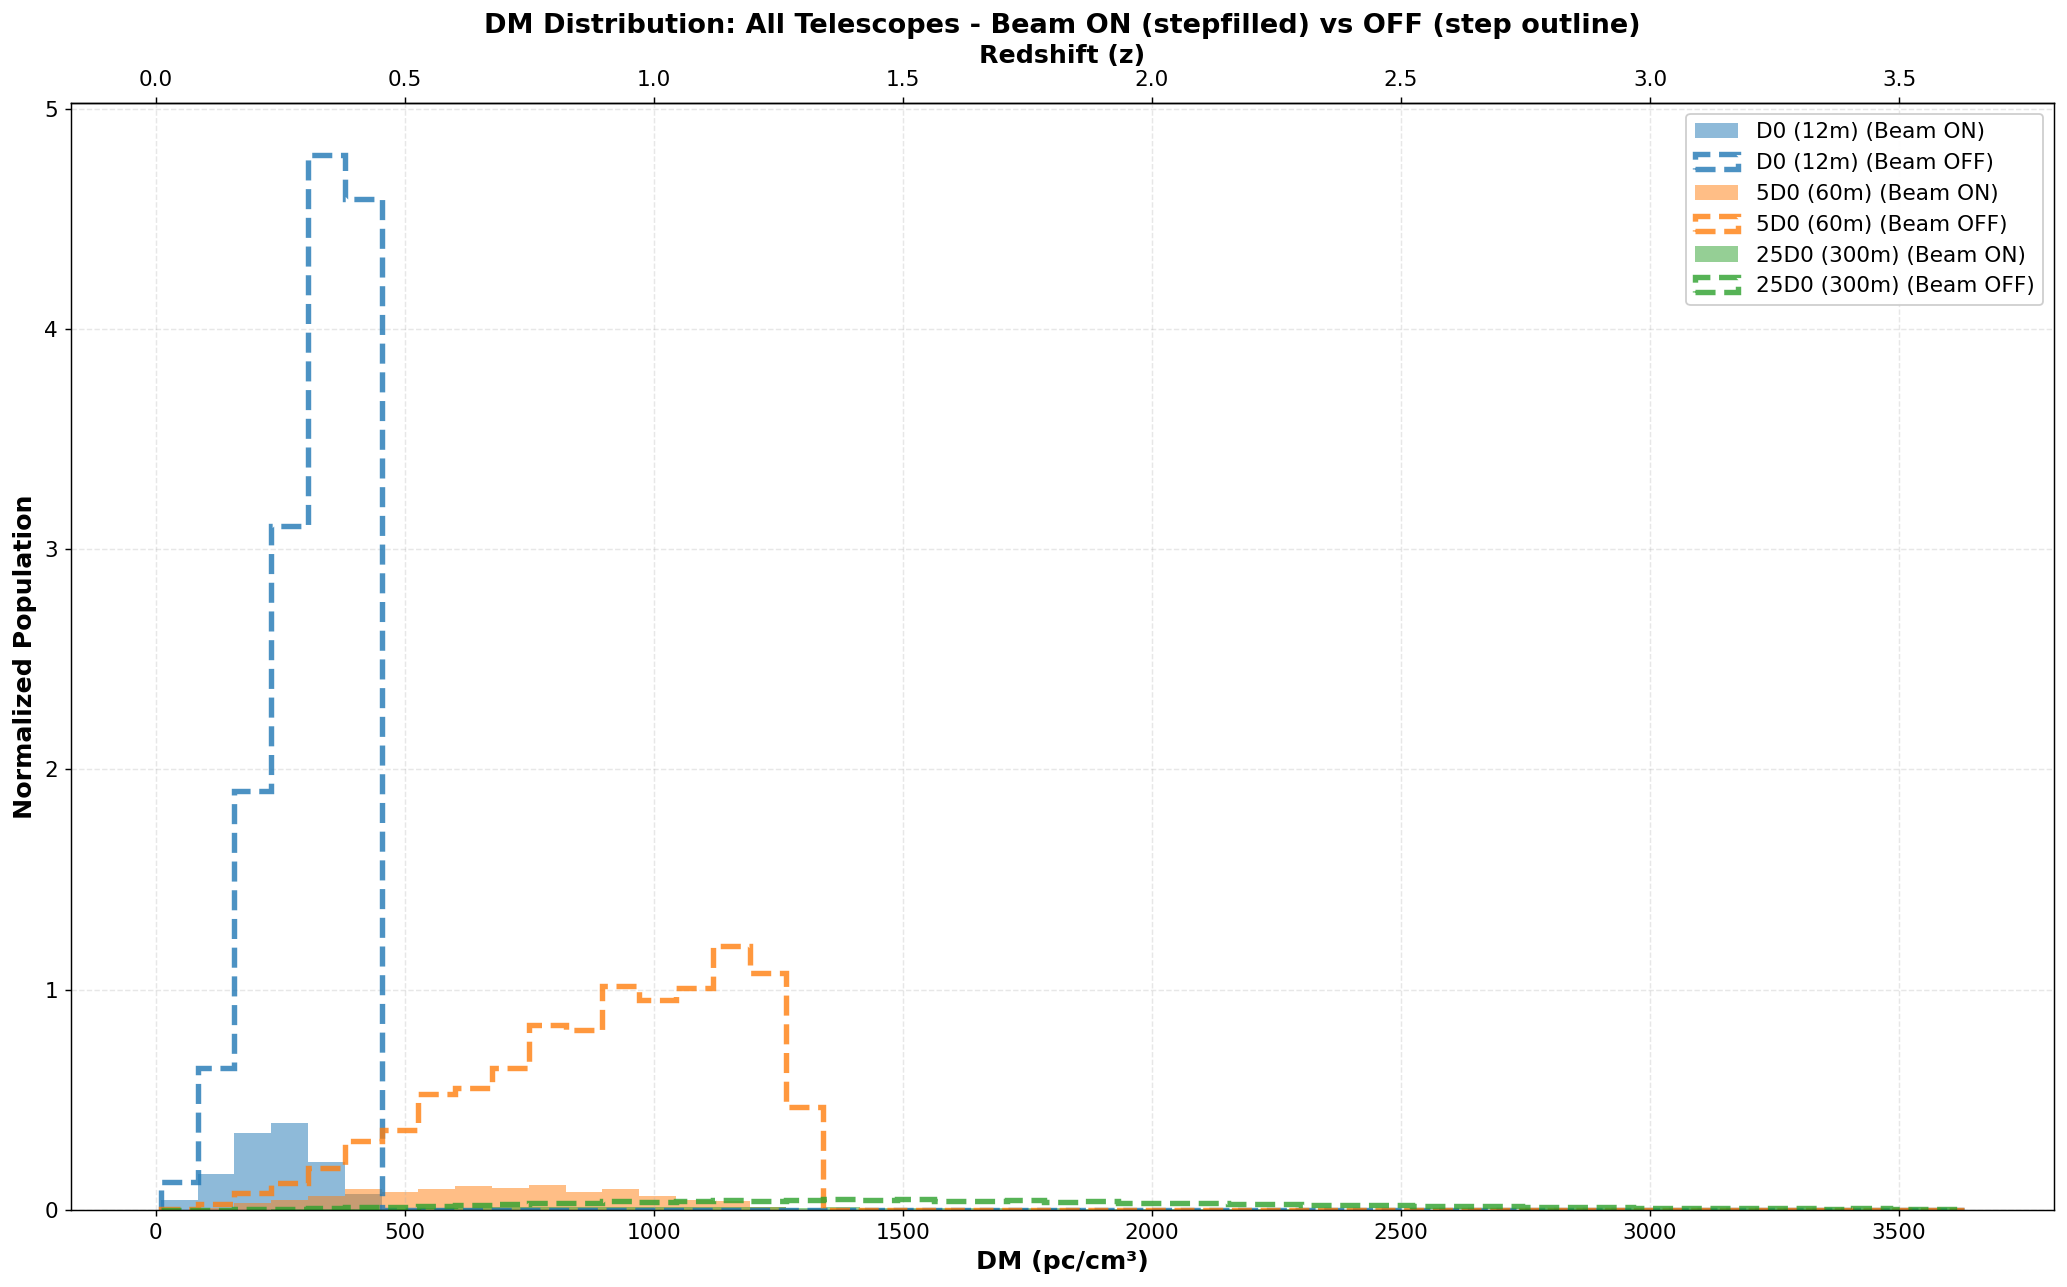


✓ Combined single-plot beam response comparison generated
   Filled histograms (stepfilled) = Beam ON
   Dashed outline (step) = Beam OFF



In [128]:
# ============================================================================
# COMBINED PLOT: ALL 3 TELESCOPES + BEAM ON/OFF (SINGLE PLOT)
# ============================================================================

fig, ax = plt.subplots(figsize=(16, 10), dpi=130)

# Find global DM range across all telescopes and beam modes
all_dms = []
for beam_mode in ['on', 'off']:
    for tel_key in ['d0', '5d0', '25d0']:
        all_dms.extend([1000*r['z'] for r in beam_results[beam_mode][tel_key]])

dm_min = min(all_dms)
dm_max = max(all_dms)
common_bins = np.linspace(dm_min, dm_max, 50)

# Get global max across all telescopes and beam modes
all_pops = []
for beam_mode in ['on', 'off']:
    for tel_key in ['d0', '5d0', '25d0']:
        pops = np.array([r['n_total_population'] for r in beam_results[beam_mode][tel_key]])
        all_pops.extend(pops)

global_max_all = max(all_pops)

# Plot for each telescope and beam mode
for tel_key in ['d0', '5d0', '25d0']:
    # BEAM ON - stepfilled histogram
    DMs_on = np.array([r['DM'] for r in beam_results['on'][tel_key]])
    pops_on = np.array([r['n_total_population'] for r in beam_results['on'][tel_key]])
    pops_normalized_on = pops_on / global_max_all
    pops_normalized_on = pops_on / global_max_all
    ax.hist(DMs_on, bins=common_bins, weights=pops_normalized_on, alpha=0.5, 
            label=f'{labels_tel[tel_key]} (Beam ON)', color=colors_tel[tel_key], 
            linewidth=2, histtype='stepfilled')
    
    # BEAM OFF - step histogram (outline only)
    DMs_off = np.array([r['DM'] for r in beam_results['off'][tel_key]])
    pops_off = np.array([r['n_total_population'] for r in beam_results['off'][tel_key]])
    pops_normalized_off = pops_off / global_max_all
    
    ax.hist(DMs_off, bins=common_bins, weights=pops_normalized_off, alpha=0.8,
            label=f'{labels_tel[tel_key]} (Beam OFF)', color=colors_tel[tel_key], 
            linewidth=3, histtype='step', linestyle='--')

# Secondary x-axis
ax2 = ax.secondary_xaxis('top', functions=(lambda x: x/1000, lambda x: x*1000))
ax2.set_xlabel('Redshift (z)', fontsize=14, fontweight='bold')
ax2.tick_params(axis='x', labelsize=12)

ax.set_xlabel('DM (pc/cm³)', fontsize=14, fontweight='bold')
ax.set_ylabel('Normalized Population', fontsize=14, fontweight='bold')
ax.set_title('DM Distribution: All Telescopes - Beam ON (stepfilled) vs OFF (step outline)', 
             fontsize=15, fontweight='bold')
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
ax.legend(fontsize=12, loc='upper right', framealpha=0.95)
# import matplotlib.patches as mpatches

# legend_handles = []
# legend_labels = []

# # Left column: ON modes
# for tel_key in ['d0', '5d0', '25d0']:
#     handle = mpatches.Patch(facecolor=colors_tel[tel_key], alpha=0.5, 
#                            edgecolor=colors_tel[tel_key], linewidth=2)
#     legend_handles.append(handle)
#     legend_labels.append(f'{labels_tel[tel_key]} (off)')

# # Right column: OFF modes
# for tel_key in ['d0', '5d0', '25d0']:
#     from matplotlib.lines import Line2D
#     handle = Line2D([0], [0], color=colors_tel[tel_key], linewidth=3, linestyle='--')
#     legend_handles.append(handle)
#     legend_labels.append(f'{labels_tel[tel_key]} (OFF)')

# ax.legend(handles=legend_handles, labels=legend_labels, fontsize=11, 
#          loc='upper right', framealpha=0.95, ncol=2)


plt.tight_layout()
plt.show()

print("\n✓ Combined single-plot beam response comparison generated")
print("   Filled histograms (stepfilled) = Beam ON")
print("   Dashed outline (step) = Beam OFF\n")